In [ ]:
"""Multiclass classification using Deep Neural Networks: Example: Use the OCR
letter recognition dataset https://archive.ics.uci.edu/ml/datasets/letter+recognition"""


In [1]:
#Import Libraries
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.datasets import mnist


In [2]:
#Load Dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


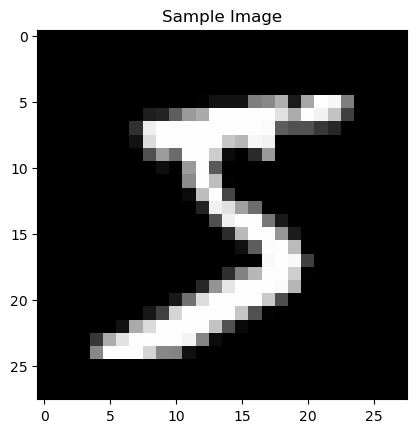

In [3]:
#Show Sample Image
plt.imshow(x_train[0], cmap='gray')
plt.title("Sample Image")
plt.show()

In [4]:
#Check Shapes
print("X_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)


X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [5]:
#Reshape Data
x_train = x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)

In [6]:
#Convert to float & Normalize
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

x_train /= 255
x_test /= 255

In [7]:
#One-Hot Encoding

num_classes = 10

y_train = np.eye(num_classes)[y_train]
y_test = np.eye(num_classes)[y_test]


In [8]:
#Build Model

model = Sequential()

model.add(Dense(512, activation='relu', input_shape=(784,)))
model.add(Dropout(0.2))

model.add(Dense(512, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(num_classes, activation='softmax'))

C:\Users\praga\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
#Compile Model

model.compile(
    loss='categorical_crossentropy',
    optimizer=RMSprop(),
    metrics=['accuracy']
)

In [10]:
#Train Model

batch_size = 128
epochs = 20

history = model.fit(
    x_train, y_train,
    batch_size=batch_size,
    epochs=epochs,
    verbose=1,
    validation_data=(x_test, y_test)
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9204 - loss: 0.2527 - val_accuracy: 0.9655 - val_loss: 0.1103
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9681 - loss: 0.1032 - val_accuracy: 0.9738 - val_loss: 0.0823
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9764 - loss: 0.0751 - val_accuracy: 0.9751 - val_loss: 0.0822
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9822 - loss: 0.0588 - val_accuracy: 0.9811 - val_loss: 0.0643
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9846 - loss: 0.0478 - val_accuracy: 0.9776 - val_loss: 0.0729
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9873 - loss: 0.0412 - val_accuracy: 0.9810 - val_loss: 0.0771
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9890 - loss: 0.0350 - val_accuracy: 0.9808 - val_loss: 0.0681
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9900 - loss: 0.0315 - val_accu

In [11]:
#Evaluate Model

score = model.evaluate(x_test, y_test)

print("Test loss:", score[0])
print("Test accuracy:", score[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9860 - loss: 0.0746
Test loss: 0.0746345967054367
Test accuracy: 0.9860000014305115


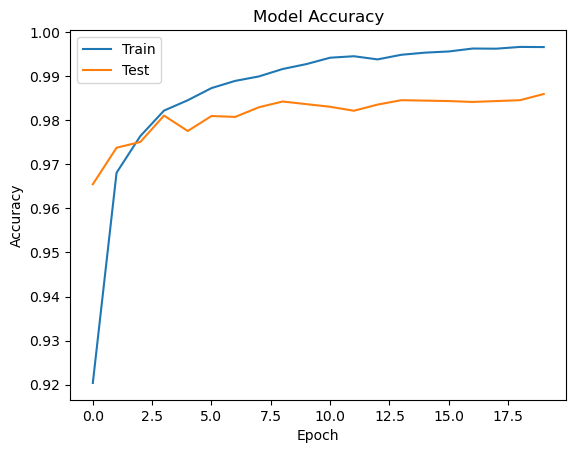

In [12]:
#Plot Accuracy

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Test'])
plt.show()

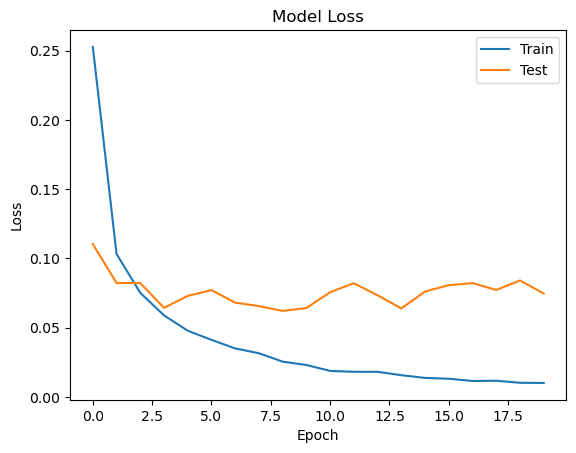

In [13]:
#Plot loss

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Test'])
plt.show()